### **NOTEBOOK 03: SAGEMAKER PIPELINE WITH POST-PIPELINE MLFLOW APP LOGGING**
#### **TEAM 04 STUDENT 3 - TING ENG KIAT (S403)**
#### **Jupyter Notebook Version: 25 August 2026**
#### **Model A: XGBoost + SMOTE**

In [1]:
# INSTALL/UPGRADE SAGEMAKER, BOTO3, BOTOCORE, MLFLOW, SAGEMAKER-MLFLOW PACKAGES
# After running, restart the kernel before continuing if packages were upgraded.
%pip install --upgrade "sagemaker>=2,<3" boto3 botocore mlflow sagemaker-mlflow


  Using cached sagemaker-2.257.6-py3-none-any.whl.metadata (19 kB)


  Using cached boto3-1.43.79-py3-none-any.whl.metadata (6.6 kB)


  Using cached botocore-1.43.79-py3-none-any.whl.metadata (5.6 kB)


  Using cached mlflow-3.15.1-py3-none-any.whl.metadata (49 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)


  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━ 12/13 [mlflow]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━ 12/13 [mlflow]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━ 12/13 [mlflow]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [mlflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
aiobotocore 3.8.0 requires botocore<1.43.47,>=1.43.3, but you have botocore 1.43.79 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.6.0 which is incompatible.
sagemaker-mlops 1.12.0 requires sagemaker-core>=2.12.0, but you have sagemaker-core 1.0.78 which is inco

Note: you may need to restart the kernel to use updated packages.


### **STEP 01: CONFIGURATION**

In [1]:
import boto3
import sagemaker
import json
import os
import time
from pathlib import Path

# ----------------------------
# AWS / SageMaker setup
# ----------------------------
session = sagemaker.Session()
role    = sagemaker.get_execution_role()
region  = boto3.Session().region_name

# Use the ITI113 course bucket and team prefix.
# This matches the team execution role S3 policy, e.g.:
# s3://nyp-26s1-iti113/iti113/team40/
BUCKET  = "nyp-26s1-iti113"

# Change these for the current student/profile.
TEAM_ID = "team04"
STUDENT_ID = "s403"

COURSE = "ITI113"
SEMESTER = "26S1"
PROJECT_NAME = "credit-card-fraud-detection"

PREFIX  = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

# Instance types.
# If ml.m5.large quota is 0, change these to an approved available training/processing type.
# For ITI113, keep Studio spaces on ml.t3.medium and use SageMaker jobs for training/processing.
PROCESSING_INSTANCE_TYPE = "ml.m5.large"
TRAINING_INSTANCE_TYPE   = "ml.m5.large"

# ----------------------------
# SageMaker Serverless MLflow App setup
# ----------------------------
# Preferred:
# 1. Team-level config copied/shared from Notebook 01A:
#       mlflow_app_config_team40.json
# 2. Student-specific config from Notebook 01A:
#       mlflow_app_config_team40_s4002.json
# 3. Any local config matching this team:
#       mlflow_app_config_team40_*.json
#
# Important:
# Do not use another team's MLflow ARN. With team-level IAM
# restriction, wrong-team access should fail with 403.
# ----------------------------

TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

config_candidates = [
    TEAM_CONFIG_FILE,
    STUDENT_CONFIG_FILE,
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]

MLFLOW_APP_ARN = None
MLFLOW_EXPERIMENT_NAME = f"{COURSE}/{TEAM_ID}/Experiment-01"
mlflow_config = {}
config_used = None

for config_file in config_candidates:
    if config_file.exists():
        mlflow_config = json.loads(config_file.read_text(encoding="utf-8"))
        MLFLOW_APP_ARN = (
            mlflow_config.get("MLFLOW_APP_ARN")
            or mlflow_config.get("mlflow_app_arn")
            or mlflow_config.get("arn")
        )
        MLFLOW_EXPERIMENT_NAME = (
            mlflow_config.get("EXPERIMENT_NAME")
            or mlflow_config.get("experiment_name")
            or MLFLOW_EXPERIMENT_NAME
        )
        MODEL_DEVELOPER_ID = mlflow_config.get("STUDENT_ID") or mlflow_config.get("student_id")
        config_used = config_file
        break

# Fallback for classroom testing only.
# Update this to your team's MLflow App ARN from Notebook 01A if the config file
# is not available in this Studio workspace.
DEFAULT_MLFLOW_APP_ARN = (
    "arn:aws:sagemaker:ap-southeast-1:044528205969:"
    "mlflow-app/app-L5IMA5YSBDTY"
)

if MLFLOW_APP_ARN is None:
    MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
    print(
        "[WARNING] No local MLflow config file found. "
        "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
    )
else:
    print(f"Loaded MLflow App config from {config_used}")

# Validate config team, if present.
config_team_id = mlflow_config.get("TEAM_ID") or mlflow_config.get("team_id")
if config_team_id and config_team_id != TEAM_ID:
    raise ValueError(
        f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
        "Do not use another team's MLflow config."
    )

# ----------------------------
# Safety check for team-level MLflow restriction
# ----------------------------
# The selected MLflow App must have ResourceTag/TeamId = TEAM_ID.
# If a student accidentally uses another team's ARN, this should either:
# - fail with AccessDenied / 403 due to IAM restriction, or
# - fail this explicit validation before logging.
# ----------------------------

sm_for_mlflow = boto3.client("sagemaker", region_name=region)

try:
    tag_response = sm_for_mlflow.list_tags(ResourceArn=MLFLOW_APP_ARN)
    mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}

    print("MLflow App tags:")
    for k, v in mlflow_app_tags.items():
        print(f"  {k}: {v}")

    app_team_id = mlflow_app_tags.get("TeamId")
    if app_team_id != TEAM_ID:
        raise PermissionError(
            f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not log to another team's MLflow App."
        )

    print(f"[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

except Exception as e:
    print("\n[ERROR] Could not validate MLflow App team tag.")
    print("This usually means one of the following:")
    print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
    print("2. The MLflow App is missing the TeamId tag.")
    print("3. The current role lacks permission to list tags for this MLflow App.")
    print(type(e).__name__, e)
    raise

# Optional: store for downstream cells and subprocesses.
os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_APP_ARN
os.environ["MLFLOW_EXPERIMENT_NAME"] = MLFLOW_EXPERIMENT_NAME


# ----------------------------
# MLflow App UI link helpers
# ----------------------------
# MLflow may print generic links such as:
# https://mlflow.sagemaker.ap-southeast-1.app.aws/#/...
# Those links are not presigned and may show a permission/session error.
# Use these helpers to generate a fresh presigned SageMaker MLflow App URL
# and append the experiment/run fragment.

def create_mlflow_app_presigned_url(fragment: str = "") -> str:
    sm_for_mlflow = boto3.client("sagemaker", region_name=region)
    response = sm_for_mlflow.create_presigned_mlflow_app_url(
        Arn=MLFLOW_APP_ARN
    )

    base_url = response.get("AuthorizedUrl") or response.get("Url")

    if not base_url:
        raise RuntimeError(
            "create_presigned_mlflow_app_url did not return AuthorizedUrl or Url. "
            f"Response: {response}"
        )

    # Remove any existing fragment before appending our own MLflow UI route.
    base_url = base_url.split("#", 1)[0]

    if fragment:
        return base_url + "#" + fragment.lstrip("#")

    return base_url


def print_mlflow_presigned_links(experiment_id=None, run_id=None):
    if experiment_id is not None:
        experiment_url = create_mlflow_app_presigned_url(
            f"/experiments/{experiment_id}"
        )
        print("Presigned MLflow experiment URL:")
        print(experiment_url)

    if experiment_id is not None and run_id is not None:
        run_url = create_mlflow_app_presigned_url(
            f"/experiments/{experiment_id}/runs/{run_id}"
        )
        print("\nPresigned MLflow run URL:")
        print(run_url)

PIPELINE_NAME       = f"iti113-{TEAM_ID}-credit-card-fraud-detection"
MODEL_PACKAGE_GROUP = f"{TEAM_ID}-credit-card-fraud-detection"
ENDPOINT_NAME       = f"iti113-{TEAM_ID}-credit-card-fraud-detection-a"
QUALITY_GATE_AUC    = 0.65

RAW_DATA_URI  = f"s3://{BUCKET}/{PREFIX}/raw/fraudTest.csv"
PIPELINE_ROOT = f"s3://{BUCKET}/{PREFIX}/pipeline"

# Store the pipeline source files in S3 first, then download them into a clean local folder.
SCRIPTS_S3_PREFIX = f"{PREFIX}/pipeline_src"
SCRIPTS_S3_URI    = f"s3://{BUCKET}/{SCRIPTS_S3_PREFIX}"

LOCAL_PIPELINE_SRC = "pipeline_src"


print(f"Pipeline                : {PIPELINE_NAME}")
print(f"Bucket                  : {BUCKET}")
print(f"Team prefix             : {PREFIX}")
print(f"Semester                : {SEMESTER}")
print(f"Region                  : {region}")
print(f"SageMaker role          : {role}")
print(f"MLflow App ARN          : {MLFLOW_APP_ARN}")
print(f"MLflow experiment       : {MLFLOW_EXPERIMENT_NAME}")
print(f"Pipeline source S3 URI  : {SCRIPTS_S3_URI}")
print(f"Local pipeline source   : {LOCAL_PIPELINE_SRC}")


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Loaded MLflow App config from mlflow_app_config_team04_s403.json
MLflow App tags:
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-5q0cdlsfisve
  ProjectName: credit-card-fraud-detection
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-5q0cdlsfisve/team04-shared
  Course: ITI113
  TeamId: team04
  CreatedByNotebook: ModelB
  StudentId: s401
[OK] MLflow App tag TeamId=team04 matches notebook TEAM_ID=team04
Pipeline                : iti113-team04-credit-card-fraud-detection
Bucket                  : nyp-26s1-iti113
Team prefix             : iti113/team04/data/credit-card-fraud-detection
Semester                : 26S1
Region                  : ap-southeast-1
SageMaker role          : arn:aws:iam::044528205969:role/SageMakerExecutionRole-ITI113-Team04
MLflow App ARN          : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
MLflow experiment       : ITI113/team04/Experiment-01
Pipeline sour

### **STEP 02: PRECHECK SAGEMAKER MLFLOW APP CONNECTION**

In [2]:
import mlflow
import time

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
experiment = mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

with mlflow.start_run(run_name=f"{TEAM_ID}_pipeline_notebook_precheck_{int(time.time())}") as run:
    mlflow.set_tags({
        "course": "ITI113",
        "semester": SEMESTER,
        "team_id": TEAM_ID,
        "student_id": STUDENT_ID,
        "dataset": "heart-disease",
        "run_type": "sagemaker_pipeline_precheck",
        "tracking_backend": "sagemaker_mlflow_app",
        "mlflow_app_arn": MLFLOW_APP_ARN,
    })
    mlflow.log_param("source", "notebook_03_precheck")
    mlflow.log_metric("connection_success", 1)

    precheck_run_id = run.info.run_id
    precheck_experiment_id = run.info.experiment_id

print("SageMaker MLflow App precheck completed.")
print("MLflow App ARN:", MLFLOW_APP_ARN)
print("Experiment:", MLFLOW_EXPERIMENT_NAME)
print("Experiment ID:", precheck_experiment_id)
print("Run ID:", precheck_run_id)
print("\nIgnore any generic mlflow.sagemaker.app.aws link printed by MLflow above.")
print("Use the presigned links below instead:")
print_mlflow_presigned_links(
    experiment_id=precheck_experiment_id,
    run_id=precheck_run_id
)


🏃 View run team04_pipeline_notebook_precheck_1787643703 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2/runs/19d5b9903f3a488cbbc9e49feaf49191
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2
SageMaker MLflow App precheck completed.
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
Experiment: ITI113/team04/Experiment-01
Experiment ID: 2
Run ID: 19d5b9903f3a488cbbc9e49feaf49191

Ignore any generic mlflow.sagemaker.app.aws link printed by MLflow above.
Use the presigned links below instead:


Presigned MLflow experiment URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IlpDVEVLNiIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNG9ZbW1GVjZCM3RDd0F5UzdtMWFUU2dFWFhpbXpwOVhrK0UwN3p0a0lGNzhBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVFMWJXSTBZMHBtZFVKSmNVbHRSVWsxYTFGNGRreDBVU3R3UkhodlMxcHFjbGxhVVdvME16Rk9XWFV2YjBveVJ6UnZVVFl2V0hwV2FETnZiazlyV25GaGR6MDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFSNkx0TGhjWmhLL2RtRkJ4YW5IRjFVQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF4ekt5VGNUTituOC9WWDlZY0NBUkNBTzh4UVo1TkdHR3JNZjZRY2RsdFlPc2ZZeU9PSlRua0hJSFp1ZEdDTkR0ZnFzSlNKK09XTWhnYnBWb1dCbk5icXZsdTFsWkZpT2hyYVFBaUFBZ0FBRUFDOFRMQXRjaXJrOU9nQmhUWUtiWVhxSlRXeDFIY3JXZVZpcTZNdkpEQ2J4QjZJSEN5V3ZaRU


Presigned MLflow run URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6Ik9HQ0ZUSCIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNGpVeVc5M3NDZjZNclUxQjBrSm4vV2VLVXJqNkNjT1Z3TUJqL3BuVzFrczBBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGblJERTNOVFZXVTJsM1JGTmxiV1F5TlZsc2NVdEVMMDlRVkdzMFlUWm1iR0ptVWprMVVHRlFRMWR1VVUxVFQyeHdkalZ2T1ZveWFEWXllRTVxV2tWRWR6MDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFjNW5SN0xoRjdtZVN3bGwyK3IzaklNQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF6UGpQTFpyYU5PekFKY1EzMENBUkNBT3ovSzFtZTdkdjE5anZEOENwV1ZSR2F2eXVrRHlYNS9nUG9FVlVBd0taS2xrcW9WUlo0Q1FlTUgyaDhFUytHVW1vSnhiZllna1hmS2dOdVBBZ0FBRUFBWFhoZzhla3RRQVNhOGxWVVZWb3UwcnN3V3pYZHI4aXNIYmFqV0owbXRCMVd4ZDlqSVMyN0kzT1Fu

### **STEP 03: WRITE PIPELINE SCRIPTS**

In [3]:
os.makedirs('src', exist_ok=True)
print('src/ directory ready')


src/ directory ready


In [4]:
%%writefile src/requirements.txt
xgboost<2.0
imbalanced-learn

Overwriting src/requirements.txt


In [5]:
%%writefile src/preprocess.py
"""SageMaker Processing Job — feature engineering, target encoding, train/valid/test split.
Feature-engineering and target-encoding logic ported from model engineer A's
team0402_ModelA_Retrain_Pipeline v1.3.ipynb (Sections 3 and 5) and inference-b843b1d0.py,
so preprocessing produces exactly the fields the new training/inference code expects.
NOTE: SELECTED_FEATURES is not sourced from feature_engineering_manifest.json (not
provided) -- it mirrors the field list the model engineer's own inference.py computes.
Confirm against the manifest when available.
"""
import argparse
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold

SELECTED_FEATURES = [
    "amt", "amt_log", "category_te", "distance_km", "distance_log",
    "city_pop", "trans_hour", "day_of_week", "is_weekend", "age", "gender_binary",
]

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    a = np.clip(a, 0.0, 1.0)
    return 2 * R * np.arcsin(np.sqrt(a))

def engineer_features(df):
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

    df["trans_hour"] = df["trans_date_trans_time"].dt.hour
    df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
    df["is_weekend"] = df["trans_date_trans_time"].dt.dayofweek.isin([5, 6]).astype(int)

    df["age"] = (
        df["trans_date_trans_time"].dt.year - df["dob"].dt.year
        - (
            (df["trans_date_trans_time"].dt.month < df["dob"].dt.month)
            | (
                (df["trans_date_trans_time"].dt.month == df["dob"].dt.month)
                & (df["trans_date_trans_time"].dt.day < df["dob"].dt.day)
            )
        ).astype(int)
    )

    df["distance_km"] = haversine_km(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
    df["distance_log"] = np.log1p(df["distance_km"])
    df["amt_log"] = np.log1p(df["amt"])
    df["gender_binary"] = df["gender"].map({"F": 0, "M": 1})
    return df

def fit_te_mapping(categories, target, smoothing=20):
    stats = target.groupby(categories).agg(["mean", "count"])
    global_mean = target.mean()
    smoothed = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
    return smoothed.to_dict(), float(global_mean)

def apply_te(categories, mapping, global_mean):
    return categories.map(mapping).fillna(global_mean).astype(float)

def kfold_target_encode(categories, target, n_splits, smoothing, random_state):
    encoded = pd.Series(index=categories.index, dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for fit_idx, hold_idx in skf.split(categories, target):
        mapping, gmean = fit_te_mapping(categories.iloc[fit_idx], target.iloc[fit_idx], smoothing)
        encoded.iloc[hold_idx] = apply_te(categories.iloc[hold_idx], mapping, gmean)
    return encoded

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--test-size", type=float, default=0.20)
    parser.add_argument("--valid-size", type=float, default=0.25)
    parser.add_argument("--random-state", type=int, default=42)
    parser.add_argument("--smoothing", type=float, default=20)
    parser.add_argument("--n-splits-te", type=int, default=5)
    args = parser.parse_args()

    base_dir = "/opt/ml/processing"
    df = pd.read_csv(f"{base_dir}/input/fraudTest.csv")
    df = engineer_features(df)

    keep_cols = [c for c in SELECTED_FEATURES if c != "category_te"] + ["category", "is_fraud"]
    keep_cols = list(dict.fromkeys(keep_cols))
    model_df = (
        df[keep_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .reset_index(drop=True)
    )

    X = model_df.drop(columns=["is_fraud"])
    y = model_df["is_fraud"].astype(int)

    X_dev, X_test, y_dev, y_test = train_test_split(
        X, y, test_size=args.test_size, stratify=y, random_state=args.random_state
    )
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_dev, y_dev, test_size=args.valid_size, stratify=y_dev, random_state=args.random_state
    )

    X_train = X_train.copy()
    X_train["category_te"] = kfold_target_encode(
        X_train["category"], y_train, args.n_splits_te, args.smoothing, args.random_state
    )

    final_mapping, final_global_mean = fit_te_mapping(X_train["category"], y_train, args.smoothing)
    X_valid = X_valid.copy(); X_test = X_test.copy()
    X_valid["category_te"] = apply_te(X_valid["category"], final_mapping, final_global_mean)
    X_test["category_te"] = apply_te(X_test["category"], final_mapping, final_global_mean)

    out_dir = Path(base_dir) / "output"
    for name, Xdf, ydf in [("train", X_train, y_train), ("valid", X_valid, y_valid), ("test", X_test, y_test)]:
        Xdf[SELECTED_FEATURES].assign(is_fraud=ydf.values).to_csv(out_dir / f"{name}.csv", index=False)

    with open(out_dir / "category_encoding.json", "w") as f:
        json.dump({"mapping": final_mapping, "global_mean": final_global_mean}, f)

    print("Preprocessing complete.")
    print(f"Train: {len(X_train)} | Valid: {len(X_valid)} | Test: {len(X_test)}")

Overwriting src/preprocess.py


In [6]:
%%writefile src/train.py
"""SageMaker Training Job — XGBoost with SMOTE, threshold selection.
Hyperparameters and threshold-selection grid ported from model engineer A's
team0402_ModelA_Retrain_Pipeline v1.3.ipynb (Sections 6-7). Saves artifacts in the
3-file format inference-b843b1d0.py expects:
    xgboost_model.json, model_a_deployment_contract.json, model_a_preprocessing_bundle.joblib
"""
import argparse
import json
import os
import joblib
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

FEATURE_COLUMNS = [
    "amt", "amt_log", "category_te", "distance_km", "distance_log",
    "city_pop", "trans_hour", "day_of_week", "is_weekend", "age", "gender_binary",
]
GENDER_MAPPING = {"F": 0, "M": 1}

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--n-estimators", type=int, default=300)
    parser.add_argument("--max-depth", type=int, default=6)
    parser.add_argument("--learning-rate", type=float, default=0.05)
    parser.add_argument("--subsample", type=float, default=0.8)
    parser.add_argument("--colsample-bytree", type=float, default=0.8)
    parser.add_argument("--random-state", type=int, default=42)
    parser.add_argument("--smote-sampling-strategy", type=float, default=0.20)
    parser.add_argument("--smote-k-neighbors", type=int, default=5)
    parser.add_argument("--team-id", type=str, default="")
    parser.add_argument("--student-id", type=str, default="")
    parser.add_argument("--semester", type=str, default="")
    parser.add_argument("--run-name", type=str, default="")
    parser.add_argument("--train", type=str, default=os.environ.get("SM_CHANNEL_TRAIN"))
    parser.add_argument("--valid", type=str, default=os.environ.get("SM_CHANNEL_VALID"))
    parser.add_argument("--test", type=str, default=os.environ.get("SM_CHANNEL_TEST"))
    parser.add_argument("--sm-model-dir", type=str, default=os.environ.get("SM_MODEL_DIR"))
    args = parser.parse_args()

    train_df = pd.read_csv(os.path.join(args.train, "train.csv"))
    valid_df = pd.read_csv(os.path.join(args.valid, "valid.csv"))
    test_df = pd.read_csv(os.path.join(args.test, "test.csv"))

    X_train, y_train = train_df[FEATURE_COLUMNS], train_df["is_fraud"]
    X_valid, y_valid = valid_df[FEATURE_COLUMNS], valid_df["is_fraud"]
    X_test, y_test = test_df[FEATURE_COLUMNS], test_df["is_fraud"]

    smote = SMOTE(
        sampling_strategy=args.smote_sampling_strategy,
        random_state=args.random_state,
        k_neighbors=args.smote_k_neighbors,
    )
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    model = XGBClassifier(
        n_estimators=args.n_estimators,
        max_depth=args.max_depth,
        learning_rate=args.learning_rate,
        subsample=args.subsample,
        colsample_bytree=args.colsample_bytree,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=args.random_state,
        n_jobs=-1,
        tree_method="hist",
    )
    model.fit(X_train_smote, y_train_smote, eval_set=[(X_valid, y_valid)], verbose=False)

    # Threshold selection on validation set — F1-maximizing, 0.01 step
    # (finer grid than before, per the model engineer's retrain notebook Section 7)
    valid_prob = model.predict_proba(X_valid)[:, 1]
    best_threshold, best_f1 = 0.5, -1
    for threshold in np.arange(0.05, 1.001, 0.01):
        pred = (valid_prob >= threshold).astype(int)
        f1 = f1_score(y_valid, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_threshold = f1, float(round(threshold, 2))

    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= best_threshold).astype(int)

    test_roc_auc = roc_auc_score(y_test, test_prob)
    test_pr_auc = average_precision_score(y_test, test_prob)
    test_precision = precision_score(y_test, test_pred, zero_division=0)
    test_recall = recall_score(y_test, test_pred, zero_division=0)
    test_f1 = f1_score(y_test, test_pred, zero_division=0)

    cm = confusion_matrix(y_test, test_pred)
    tn, fp, fn, tp = cm.ravel()
    test_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    test_fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # NOTE: print format below must stay exact -- the pipeline's TrainingStep
    # metric_definitions regex (STEP 06, "STEP 2: TRAININGSTEP" cell) parses these lines.
    print(f"Test ROC-AUC: {test_roc_auc:.4f}")
    print(f"Test PR-AUC: {test_pr_auc:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test FPR: {test_fpr:.6f}")
    print(f"Test FNR: {test_fnr:.6f}")
    print(f"Selected Threshold: {best_threshold:.2f}")

    with open(os.path.join(args.train, "category_encoding.json")) as f:
        encoding_info = json.load(f)

    # --- Save artifacts in the 3-file format the new inference.py expects ---
    model.save_model(os.path.join(args.sm_model_dir, "xgboost_model.json"))

    preprocessing_bundle = {
        "category_te_mapping": encoding_info["mapping"],
        "category_te_global_mean": encoding_info["global_mean"],
        "gender_mapping": GENDER_MAPPING,
        "operating_threshold": best_threshold,
    }
    joblib.dump(preprocessing_bundle, os.path.join(args.sm_model_dir, "model_a_preprocessing_bundle.joblib"))

    raw_input_fields_required = [
        {"category_te": "category", "gender_binary": "gender"}.get(c, c) for c in FEATURE_COLUMNS
    ]
    deployment_contract = {
        "feature_columns": FEATURE_COLUMNS,
        "raw_input_fields_required": raw_input_fields_required,
        "operating_threshold": best_threshold,
        "decision_rule": "fraud if predicted_probability >= operating_threshold",
    }
    with open(os.path.join(args.sm_model_dir, "model_a_deployment_contract.json"), "w") as f:
        json.dump(deployment_contract, f, indent=2)

    print("Model artifacts saved: xgboost_model.json, model_a_preprocessing_bundle.joblib, model_a_deployment_contract.json")

Overwriting src/train.py


In [7]:
%%writefile src/inference.py
"""SageMaker inference handler — accepts raw transaction JSON.
Ported from model engineer A's inference-b843b1d0.py. Implements the four
SageMaker "Bring Your Own Script" hooks: model_fn, input_fn, predict_fn, output_fn.
Expects model_dir to contain: xgboost_model.json, model_a_deployment_contract.json,
model_a_preprocessing_bundle.joblib (all produced by the new train.py).
"""
import json
import os

import joblib
import numpy as np
import pandas as pd
from xgboost import XGBClassifier


def _haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    a = np.clip(a, 0.0, 1.0)
    return 2 * R * np.arcsin(np.sqrt(a))


RAW_TRANSACTION_FIELDS = [
    "trans_date_trans_time", "dob", "lat", "long", "merch_lat", "merch_long",
    "amt", "category", "city_pop", "gender",
]


def _apply_feature_engineering(df):
    """Raw transaction fields -> Feature-Engineering-level fields."""
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

    df["trans_hour"] = df["trans_date_trans_time"].dt.hour
    df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
    df["is_weekend"] = df["trans_date_trans_time"].dt.dayofweek.isin([5, 6]).astype(int)

    df["age"] = (
        df["trans_date_trans_time"].dt.year - df["dob"].dt.year
        - (
            (df["trans_date_trans_time"].dt.month < df["dob"].dt.month)
            | (
                (df["trans_date_trans_time"].dt.month == df["dob"].dt.month)
                & (df["trans_date_trans_time"].dt.day < df["dob"].dt.day)
            )
        ).astype(int)
    )

    df["distance_km"] = _haversine_km(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
    df["distance_log"] = np.log1p(df["distance_km"])
    df["amt_log"] = np.log1p(df["amt"])
    return df


def _apply_target_encoding(df, model_bundle):
    """Feature-Engineering-level fields -> model-ready numeric matrix."""
    df = df.copy()
    bundle = model_bundle["preprocessing_bundle"]
    contract = model_bundle["contract"]

    te_mapping = bundle["category_te_mapping"]
    te_global_mean = bundle["category_te_global_mean"]
    gender_mapping = bundle["gender_mapping"]

    df["category_te"] = df["category"].map(te_mapping).fillna(te_global_mean).astype(float)
    df["gender_binary"] = df["gender"].map(gender_mapping)

    feature_columns = contract["feature_columns"]
    missing = [c for c in feature_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Preprocessing did not produce all required model features: {missing}")

    return df[feature_columns].apply(pd.to_numeric, errors="coerce")


def model_fn(model_dir):
    """Load the model and its companion artifacts once, at container startup."""
    xgb_model = XGBClassifier()
    xgb_model.load_model(os.path.join(model_dir, "xgboost_model.json"))

    with open(os.path.join(model_dir, "model_a_deployment_contract.json"), "r", encoding="utf-8") as f:
        contract = json.load(f)

    preprocessing_bundle = joblib.load(os.path.join(model_dir, "model_a_preprocessing_bundle.joblib"))

    return {
        "model": xgb_model,
        "contract": contract,
        "preprocessing_bundle": preprocessing_bundle,
        "operating_threshold": float(contract["operating_threshold"]),
    }


def input_fn(request_body, request_content_type):
    """Parse the incoming request into a DataFrame of one or more transactions."""
    if request_content_type != "application/json":
        raise ValueError(
            f"Unsupported content type: {request_content_type}. Expected application/json."
        )
    payload = json.loads(request_body)
    records = payload if isinstance(payload, list) else [payload]
    return pd.DataFrame.from_records(records)


def predict_fn(input_data, model_bundle):
    """
    Route based on which fields are present:
    - raw transaction fields (lat/long/dob/trans_date_trans_time present)
      -> apply Feature Engineering transforms first
    - already Feature-Engineering-level fields -> skip straight to encoding
    """
    has_raw_fields = all(c in input_data.columns for c in RAW_TRANSACTION_FIELDS)

    if has_raw_fields:
        engineered = _apply_feature_engineering(input_data)
    else:
        contract = model_bundle["contract"]
        missing = [c for c in contract["raw_input_fields_required"] if c not in input_data.columns]
        if missing:
            raise ValueError(
                "Input is missing required fields (the contract expects either genuinely "
                f"raw transaction fields, or these Feature-Engineering-level fields): {missing}"
            )
        engineered = input_data

    X = _apply_target_encoding(engineered, model_bundle)

    probability = model_bundle["model"].predict_proba(X)[:, 1]
    threshold = model_bundle["operating_threshold"]
    prediction = (probability >= threshold).astype(int)

    return pd.DataFrame({
        "fraud_probability": probability,
        "is_fraud_predicted": prediction,
        "operating_threshold": threshold,
    })


def output_fn(prediction, response_content_type):
    """Serialise the prediction DataFrame back to the response payload."""
    if response_content_type != "application/json":
        raise ValueError(
            f"Unsupported accept type: {response_content_type}. Expected application/json."
        )
    return json.dumps(prediction.to_dict(orient="records")), response_content_type

Overwriting src/inference.py


In [8]:
# CONFIRM PREPROCESS.PY, TRAIN.PY, INFERENCE.PY WERE WRITTEN LOCALLY (PRINT FILE SIZES)
# No MLflow requirements file is needed in the SageMaker training container.
# MLflow logging is done after the pipeline completes, from this notebook.
# The training script now saves a joblib deployment bundle containing:
#   - trained model
#   - fitted scaler
#   - missing-value fill values
#   - raw and processed feature column order

print("Scripts written:")
for fn in ["preprocess.py", "train.py", "inference.py"]:
    size = os.path.getsize(f"src/{fn}")
    print(f"  src/{fn}  ({size} bytes)")

Scripts written:
  src/preprocess.py  (5452 bytes)
  src/train.py  (6185 bytes)
  src/inference.py  (5698 bytes)


### **STEP 04: UPLOAD PIPELINE SOURCE FILES TO S3**

In [9]:
from pathlib import Path

s3_client = boto3.client("s3")

SOURCE_DIR = Path("src")
FILES_TO_UPLOAD = [
    "preprocess.py",
    "train.py",
    "inference.py",
    "requirements.txt", # NEW TEK | 13 AUG 2026
]

for filename in FILES_TO_UPLOAD:
    local_path = SOURCE_DIR / filename
    s3_key = f"{SCRIPTS_S3_PREFIX}/{filename}"

    if not local_path.exists():
        raise FileNotFoundError(f"Missing local source file: {local_path}")

    s3_client.upload_file(str(local_path), BUCKET, s3_key)
    print(f"Uploaded {local_path} -> s3://{BUCKET}/{s3_key}")

print("Pipeline source files uploaded to:", SCRIPTS_S3_URI)

Uploaded src/preprocess.py -> s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/preprocess.py
Uploaded src/train.py -> s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/train.py
Uploaded src/inference.py -> s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/inference.py
Uploaded src/requirements.txt -> s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/requirements.txt
Pipeline source files uploaded to: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src


### **STEP 05: DOWNLOAD PIPELINE SOURCE FILES FROM S3**

In [10]:
import shutil

local_src = Path(LOCAL_PIPELINE_SRC)

if local_src.exists():
    shutil.rmtree(local_src)

local_src.mkdir(parents=True, exist_ok=True)

for filename in FILES_TO_UPLOAD:
    s3_key = f"{SCRIPTS_S3_PREFIX}/{filename}"
    local_path = local_src / filename

    s3_client.download_file(BUCKET, s3_key, str(local_path))
    print(f"Downloaded s3://{BUCKET}/{s3_key} -> {local_path}")

print("Downloaded files:")
for p in sorted(local_src.iterdir()):
    print("-", p)

Downloaded s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/preprocess.py -> pipeline_src/preprocess.py
Downloaded s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/train.py -> pipeline_src/train.py
Downloaded s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/inference.py -> pipeline_src/inference.py
Downloaded s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/requirements.txt -> pipeline_src/requirements.txt
Downloaded files:
- pipeline_src/inference.py
- pipeline_src/preprocess.py
- pipeline_src/requirements.txt
- pipeline_src/train.py


### **STEP 06: DEFINE THE SAGEMAKER PIPELINE**

In [11]:
from sagemaker.workflow.pipeline import Pipeline
from sagemaker.workflow.steps import ProcessingStep, TrainingStep
from sagemaker.workflow.conditions import ConditionGreaterThanOrEqualTo
from sagemaker.workflow.condition_step import ConditionStep
from sagemaker.workflow.functions import JsonGet
from sagemaker.workflow.parameters import ParameterFloat, ParameterInteger
from sagemaker.workflow.model_step import ModelStep
from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.sklearn.estimator import SKLearn
from sagemaker.processing import ProcessingInput, ProcessingOutput
from sagemaker.model import Model
from sagemaker.workflow.pipeline_context import PipelineSession

pipeline_session = PipelineSession()

# Pipeline parameters — can be overridden at execution time
p_n_est    = ParameterInteger(name='NEstimators',    default_value=200)
p_depth    = ParameterInteger(name='MaxDepth',       default_value=6)

# p_samples  = ParameterInteger(name='MinSamplesLeaf', default_value=4)
p_lr          = ParameterFloat(  name='LearningRate',     default_value=0.05)
p_subsample   = ParameterFloat(  name='Subsample',        default_value=0.8)
p_colsample   = ParameterFloat(  name='ColsampleBytree',  default_value=0.8)

p_gate     = ParameterFloat(  name='QualityGateAUC', default_value=QUALITY_GATE_AUC)

print('Pipeline parameters defined.')

Pipeline parameters defined.


In [12]:
# STEP 1: PROCESSINGSTEP

processor = SKLearnProcessor(
    framework_version='1.2-1', instance_type=PROCESSING_INSTANCE_TYPE,
    instance_count=1, role=role, sagemaker_session=pipeline_session,
    base_job_name=f'iti113-{TEAM_ID}-{STUDENT_ID}-process')

step_process = ProcessingStep(
    name='Team04-PreprocessData',
    processor=processor,
    inputs=[ProcessingInput(source=RAW_DATA_URI,
                            destination='/opt/ml/processing/input')],
    outputs=[ProcessingOutput(output_name='processed',
                              source='/opt/ml/processing/output',
                              destination=f'{PIPELINE_ROOT}/processed')],
    code=f'{LOCAL_PIPELINE_SRC}/preprocess.py',
    job_arguments=['--test-size','0.2','--random-state','42']
)
print('Step 1 (ProcessingStep) defined.')


INFO:sagemaker.image_uris:Defaulting to only available Python version: py3


/opt/conda/lib/python3.12/site-packages/sagemaker/processing.py:138: SageMakerV2DeprecationWarning: SKLearnProcessor is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `DataProcessor` (`from sagemaker.mlops.processing import DataProcessor`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Step 1 (ProcessingStep) defined.


In [13]:
# STEP 2: TRAININGSTEP
# The training container receives no Databricks host, token, or MLflow dependency.
# It only trains the model and prints metrics for SageMaker to capture.

estimator = SKLearn(
    entry_point="train.py",
    source_dir=LOCAL_PIPELINE_SRC,
    dependencies=[f'{LOCAL_PIPELINE_SRC}/requirements.txt'],
    framework_version="1.2-1",
    instance_type=TRAINING_INSTANCE_TYPE,
    instance_count=1,
    role=role,
    base_job_name=f"iti113-{TEAM_ID}-{STUDENT_ID}-train",
    sagemaker_session=pipeline_session,
    hyperparameters={
        "n-estimators": p_n_est,
        "max-depth": p_depth,

        "learning-rate": p_lr,
        "subsample": p_subsample,
        "colsample-bytree": p_colsample,

        "random-state": 42,
        "team-id": TEAM_ID,
        "student-id": STUDENT_ID,
        "semester": SEMESTER,
        "run-name": "sagemaker_pipeline_run",
    },
    environment={
        "TEAM_ID": TEAM_ID,
        "STUDENT_ID": STUDENT_ID,
        "SEMESTER": SEMESTER,
    },

    metric_definitions=[
        {"Name": "test_auc_roc", "Regex": "Test ROC-AUC: ([0-9\\.]+)"},
        {"Name": "test_pr_auc", "Regex": "Test PR-AUC: ([0-9\\.]+)"},
        {"Name": "test_precision", "Regex": "Test Precision: ([0-9\\.]+)"},
        {"Name": "test_recall", "Regex": "Test Recall: ([0-9\\.]+)"},
        {"Name": "test_f1", "Regex": "Test F1: ([0-9\\.]+)"},
        {"Name": "test_fpr", "Regex": "Test FPR: ([0-9\\.]+)"},
        {"Name": "test_fnr", "Regex": "Test FNR: ([0-9\\.]+)"},
],

    tags=[
        {"Key": "Course", "Value": "ITI113"},
        {"Key": "Semester", "Value": SEMESTER},
        {"Key": "Team", "Value": TEAM_ID},
        {"Key": "Student", "Value": STUDENT_ID},
    ],
)

processed_uri = step_process.properties.ProcessingOutputConfig.Outputs["processed"].S3Output.S3Uri

step_train = TrainingStep(
    name="Team04-TrainModel",
    estimator=estimator,
    inputs={
        "train": sagemaker.inputs.TrainingInput(
            s3_data=processed_uri,
            content_type="text/csv"
        ),
        "test": sagemaker.inputs.TrainingInput(
            s3_data=processed_uri,
            content_type="text/csv"
        ),

        "valid": sagemaker.inputs.TrainingInput(
            s3_data=processed_uri,
            content_type="text/csv"
        ),

        "preprocessor": sagemaker.inputs.TrainingInput(
            s3_data=processed_uri,
            content_type="application/octet-stream"
        ),
    },
)

print("Step 2 (TrainingStep) defined.")

/opt/conda/lib/python3.12/site-packages/sagemaker/estimator.py:588: SageMakerV2DeprecationWarning: SKLearn is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Step 2 (TrainingStep) defined.


In [14]:
# STEP 3: MODELSTEP — REGISTER IN SAGEMAKER MODEL REGISTRY

model = Model(
    image_uri=estimator.training_image_uri(),
    model_data=step_train.properties.ModelArtifacts.S3ModelArtifacts,
    sagemaker_session=pipeline_session,
    role=role,
    entry_point='inference.py',
    source_dir=LOCAL_PIPELINE_SRC
)
step_register = ModelStep(
    name='Team04-RegisterModel',
    step_args=model.register(
        content_types=['application/json'],
        response_types=['application/json'],
        inference_instances=['ml.m5.large'],
        transform_instances=['ml.m5.large'],
        model_package_group_name=MODEL_PACKAGE_GROUP,
        approval_status='PendingManualApproval',
    )
)
print('Step 3 (ModelStep) defined.')


/opt/conda/lib/python3.12/site-packages/sagemaker/model.py:347: SageMakerV2DeprecationWarning: Model is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


/opt/conda/lib/python3.12/site-packages/sagemaker/workflow/pipeline_context.py:332: UserWarning: Running within a PipelineSession, there will be No Wait, No Logs, and No Job being started.
  warnings.warn(


Step 3 (ModelStep) defined.


In [15]:
# STEP 4: CONDITIONSTEP — GATE ON SAGEMAKER-CAPTURED TEST AUC

# The training script prints:
#     Test AUC-ROC: 0.xxxx
# and the estimator metric_definitions capture this as "test_auc_roc".
# This avoids relying on Databricks Model Registry or a separate evaluation file.
condition = ConditionGreaterThanOrEqualTo(
    left=step_train.properties.FinalMetricDataList["test_pr_auc"].Value,
    right=p_gate
)

# step_register need to be declared first before used in step_condition
# and that is why register cell comes before condition cell
# NOTE: step_register (defined above) is only referenced here as a Python
# object — it does NOT execute until AFTER this condition passes.
# Cell order != execution order. Actual order:
#   PreprocessData -> TrainModel -> AUCQualityGate -> RegisterModel

step_condition = ConditionStep(
    name="Team04-AUCQualityGate",
    conditions=[condition],
    if_steps=[step_register],
    else_steps=[]
)
print("Step 4 (ConditionStep) defined.")


Step 4 (ConditionStep) defined.


In [16]:
# STEP 5: ASSEMBLE AND UPSERT THE PIPELINE

pipeline = Pipeline(
    name=PIPELINE_NAME,

    parameters=[p_n_est, p_depth, p_lr, p_subsample, p_colsample, p_gate],

    steps=[step_process, step_train, step_condition], # step_register nested inside step_condition
    sagemaker_session=pipeline_session
)
pipeline.upsert(role_arn=role)
print(f'Pipeline "{PIPELINE_NAME}" upserted.')
print('View in SageMaker Studio: left sidebar -> Pipelines')

/opt/conda/lib/python3.12/site-packages/sagemaker/workflow/pipeline.py:119: SageMakerV2DeprecationWarning: Pipeline is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `Pipeline` (`from sagemaker.mlops.pipeline import Pipeline`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


Pipeline "iti113-team04-credit-card-fraud-detection" upserted.
View in SageMaker Studio: left sidebar -> Pipelines


### **STEP 07: EXECUTE THE PIPELINE**

In [17]:
from datetime import datetime
from zoneinfo import ZoneInfo

sg_time = datetime.now(ZoneInfo("Asia/Singapore"))

execution = pipeline.start(
    execution_display_name=f"Team04-{sg_time.strftime('%Y%m%d-%H%M%S')}",
    parameters={
        'NEstimators': 300, 'MaxDepth': 6, 'LearningRate': 0.05,
        'Subsample': 0.8, 'ColsampleBytree': 0.8, 'QualityGateAUC': 0.65
    }
)

print(f'Execution ARN: {execution.arn}')
print(f'Execution display name: Team04-{sg_time.strftime("%Y%m%d-%H%M%S")} (Singapore time)')
print('Monitoring step status below. Takes ~10-15 minutes.')

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


Execution ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:pipeline/iti113-team04-credit-card-fraud-detection/execution/djwiy8twj1a9
Execution display name: Team04-20260825-154256 (Singapore time)
Monitoring step status below. Takes ~10-15 minutes.


In [18]:
# POLLING LOOP

import time

prev = {}

while True:

    desc = execution.describe() # fetches the pipeline's overall status (Executing, Succeeded, Failed, Stopped)
    status = desc["PipelineExecutionStatus"]

    steps = execution.list_steps() # fetches each individual step's status (PreprocessData, TrainModel, AUCQualityGate, RegisterModel)

    # Compatible with both old and new SageMaker SDKs
    if isinstance(steps, dict):
        steps = steps.get("PipelineExecutionSteps", [])

    for step in steps:
        n = step["StepName"]
        s = step["StepStatus"]

        if prev.get(n) != s:
            print(f"{n:<20} {s}")
            prev[n] = s

    if status in ("Succeeded", "Failed", "Stopped"):
        print(f"\nPipeline Status: {status}")
        break

    time.sleep(30)


Team04-PreprocessData Starting


Team04-PreprocessData Executing


Team04-TrainModel    Executing
Team04-PreprocessData Succeeded


Team04-RegisterModel-RepackModel-0 Executing
Team04-AUCQualityGate Succeeded
Team04-TrainModel    Succeeded


Team04-RegisterModel-RegisterModel Succeeded
Team04-RegisterModel-RepackModel-0 Succeeded

Pipeline Status: Succeeded


### **STEP 08: LOG THE COMPLETED SAGEMAKER RUN TO THE MLFLOW APP**

In [19]:
# Run only after the execution-monitoring cell reports "Pipeline Succeeded".
# In SageMaker SDK 2.257.3, execution.list_steps() returns a Python list.
# The compatibility helper also supports SDK versions that return a dictionary.
import mlflow
import boto3
import json
import time

def get_pipeline_steps(execution):
    response = execution.list_steps()
    if isinstance(response, list):
        return response
    return response.get("PipelineExecutionSteps", [])


if execution.describe()["PipelineExecutionStatus"] != "Succeeded":
    raise RuntimeError(
        "The SageMaker Pipeline has not succeeded. "
        "Resolve pipeline failures before logging to MLflow."
    )

steps = get_pipeline_steps(execution)

print("Pipeline steps:")
for step in steps:
    print(f"  {step['StepName']}: {step['StepStatus']}")

train_step_info = next(
    (
        step for step in steps
        if step["StepName"] == "Team04-TrainModel"
        and step["StepStatus"] == "Succeeded"
    ),
    None
)

if train_step_info is None:
    raise RuntimeError(
        "A successful TrainModel step was not found in this pipeline execution."
    )

training_job_arn = train_step_info["Metadata"]["TrainingJob"]["Arn"]
training_job_name = training_job_arn.rsplit("/", 1)[-1]

sm_client = boto3.client("sagemaker", region_name=region)
training_job = sm_client.describe_training_job(
    TrainingJobName=training_job_name
)

# SageMaker captures the metrics printed by train.py through metric_definitions.
captured_metrics = {
    item["MetricName"]: float(item["Value"])
    for item in training_job.get("FinalMetricDataList", [])
    if item["MetricName"] in {
        "test_auc_roc", "test_pr_auc", "test_precision",
        "test_recall", "test_f1", "test_fpr", "test_fnr",
    }
}

if not captured_metrics:
    raise RuntimeError(
        "No captured SageMaker metrics were found. "
        "Check train.py output and estimator.metric_definitions."
    )

model_artifact_s3_uri = training_job["ModelArtifacts"]["S3ModelArtifacts"]
training_hyperparameters = training_job.get("HyperParameters", {})

print("Training job:", training_job_name)
print("Model artefact:", model_artifact_s3_uri)
print("Captured metrics:", captured_metrics)

# Log to SageMaker Serverless MLflow App.
mlflow.set_tracking_uri(MLFLOW_APP_ARN)
experiment = mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

mlflow_run_name = (
    f"{TEAM_ID}_{STUDENT_ID}_sagemaker_pipeline_"
    f"{int(time.time())}"
)

with mlflow.start_run(run_name=mlflow_run_name) as run:
    mlflow.set_tags({
        "course": "ITI113",
        "semester": SEMESTER,
        "team_id": TEAM_ID,
        "student_id": STUDENT_ID,
        "model_developer_id": MODEL_DEVELOPER_ID,
        "dataset": "credit-card-fraud-detection", 
        "execution_environment": "aws_sagemaker_pipeline",
        "tracking_backend": "sagemaker_mlflow_app",
        "pipeline_execution_arn": execution.arn,
        "training_job_name": training_job_name,
        "sagemaker_model_artifact_s3_uri": model_artifact_s3_uri,
        "mlflow_app_arn": MLFLOW_APP_ARN,
        "mlflow_experiment": MLFLOW_EXPERIMENT_NAME,
    })

    # Hyperparameters arrive from SageMaker as strings, which are valid MLflow params.
    mlflow.log_params(training_hyperparameters)
    mlflow.log_metrics(captured_metrics)

    # Store a small, portable traceability record as an MLflow artefact.
    run_summary = {
        "pipeline_execution_arn": execution.arn,
        "training_job_name": training_job_name,
        "training_job_arn": training_job_arn,
        "model_artifact_s3_uri": model_artifact_s3_uri,
        "metrics": captured_metrics,
        "hyperparameters": training_hyperparameters,
        "team_id": TEAM_ID,
        "student_id": STUDENT_ID,
        "semester": SEMESTER,
        "mlflow_app_arn": MLFLOW_APP_ARN,
        "mlflow_experiment": MLFLOW_EXPERIMENT_NAME,
        "tracking_backend": "sagemaker_mlflow_app",
    }

    summary_file = "sagemaker_pipeline_run_summary.json"
    with open(summary_file, "w") as f:
        json.dump(run_summary, f, indent=2)

    mlflow.log_artifact(
        summary_file,
        artifact_path="sagemaker_pipeline"
    )

    mlflow_run_id = run.info.run_id
    mlflow_experiment_id = run.info.experiment_id

print("SageMaker MLflow App logging completed.")
print("MLflow run ID:", mlflow_run_id)
print("MLflow App ARN:", MLFLOW_APP_ARN)
print("Experiment:", MLFLOW_EXPERIMENT_NAME)
print("Experiment ID:", mlflow_experiment_id)
print("\nIgnore any generic mlflow.sagemaker.app.aws link printed by MLflow above.")
print("Use the presigned links below instead:")
print_mlflow_presigned_links(
    experiment_id=mlflow_experiment_id,
    run_id=mlflow_run_id
)


Pipeline steps:
  Team04-RegisterModel-RegisterModel: Succeeded
  Team04-RegisterModel-RepackModel-0: Succeeded
  Team04-AUCQualityGate: Succeeded
  Team04-TrainModel: Succeeded
  Team04-PreprocessData: Succeeded
Training job: pipelines-djwiy8twj1a9-Team04-TrainModel-ZXYPIcm1bE
Model artefact: s3://sagemaker-ap-southeast-1-044528205969/pipelines-djwiy8twj1a9-Team04-TrainModel-ZXYPIcm1bE/output/model.tar.gz
Captured metrics: {'test_fpr': 0.0005150000215508044, 'test_auc_roc': 0.989799976348877, 'test_fnr': 0.37296000123023987, 'test_precision': 0.8252000212669373, 'test_recall': 0.6269999742507935, 'test_pr_auc': 0.7509999871253967, 'test_f1': 0.7125999927520752}


🏃 View run team04_s403_sagemaker_pipeline_1787644538 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2/runs/8413e062feb5466bbaca332a008f2b1a
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2
SageMaker MLflow App logging completed.
MLflow run ID: 8413e062feb5466bbaca332a008f2b1a
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
Experiment: ITI113/team04/Experiment-01
Experiment ID: 2

Ignore any generic mlflow.sagemaker.app.aws link printed by MLflow above.
Use the presigned links below instead:


Presigned MLflow experiment URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IjJMN05IVyIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDBmQ01MV2JWb29oS3BjdHpCYjR6VExCaDg1M3hQOTRtencyd1pRKy9hWGNBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGMmIyTlJkVkZSU1ZsRlZ6TlFWU3R1U2t0Qk1XWlpNWEpaWms5V04wOTFVRVI2YlhGM2IwRkpVU3RhTWt0c2FIQmtlVEpDTWxBNFRVaDZLMlJ3WVROMWR6MDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFWTVpydE50Uys3dlo3L1cza243N3VRQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF6N0RxTjYxQVBleWcrRjhnQUNBUkNBT3k1N0xCcXAzWW14ZkVqQUVLNVhud082NEF0aXkvYkRoTTNpamZmL1Y4U3NIN1daMGIyWEtPSVNIOHltZktvNnlSdGJDVG5abTA2M05jN0VBZ0FBRUFBcjlGMUFacUlzcVB5Z0Z6c0NablFvTlo3UUtUZVJ5ZHAzQmkybTAvRUNlZXdPWGowc0tWOX


Presigned MLflow run URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IlNGUzVVTCIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNEJUNzA2dS9oMU5MTXNEK3h0eS96aUZIcWRZamo2NG1PdXY5dFhyNGgzLzhBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGcVV6TnpiRWhGVEVKSlIycFlVRGhNVWtwWGFEbE5SalZFVnpaeksyaGpWalZtSzFOTlEyaHdTWG8xWm1oQmMzcHVZVzgyUTJGRldWRkxPR3B1ZG1GdGR6MDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFaRkJSZTdQUUlMNUtCVDZOa0h3SXY4QUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF6bU1sUXJNZWIrRno2Sjh4b0NBUkNBT3drNnJPN25oV2c0eUsrdFpyb2xTcktyRWtkYTZDYjdLMkR0Y3ZuekZ1ZUlHKzdMOWdHMXJFeitFV3RYUndENnJZMEV0SzRsQVJLYUwyQitBZ0FBRUFCRmJCYldLU3NEbWFMazFWZ3FXUlZrbGJweExTdnM0dzRVNVFJbGxIaVlEaWEwc1V0M1hzK2xSTmU5

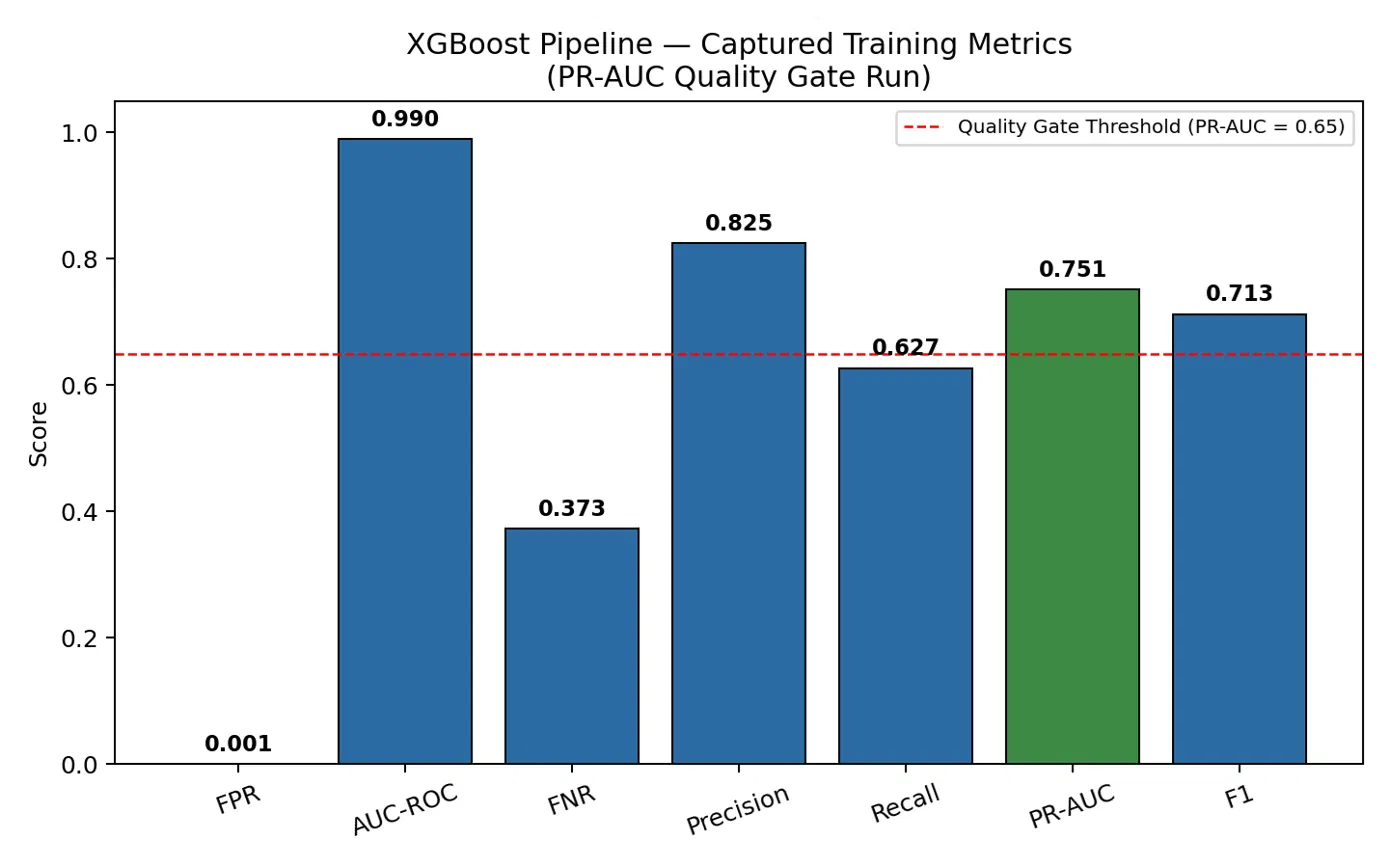

### **STEP 09: DEPLOY SERVERLESS ENDPOINT**

In [20]:
# FETCH LATEST REGISTERED MODEL PACKAGE FROM MODEL REGISTRY AND SHOW APPROVAL STATUS

sm = boto3.client('sagemaker')

# Get the latest registered model package
pkgs = sm.list_model_packages(
    ModelPackageGroupName=MODEL_PACKAGE_GROUP,
    SortBy='CreationTime', SortOrder='Descending', MaxResults=1
)['ModelPackageSummaryList']

if not pkgs:
    print('No model packages found. Check the pipeline completed the Register step.')
else:
    pkg_arn = pkgs[0]['ModelPackageArn']
    print(f'Model package : {pkg_arn}')
    print(f'Status        : {pkgs[0]["ModelApprovalStatus"]}')

Model package : arn:aws:sagemaker:ap-southeast-1:044528205969:model-package/team04-credit-card-fraud-detection/41
Status        : PendingManualApproval


In [21]:
# APPROVE THE LATEST MODEL PACKAGE

sm.update_model_package(ModelPackageArn=pkg_arn, ModelApprovalStatus='Approved')
print(f'Approved: {pkg_arn}')


Approved: arn:aws:sagemaker:ap-southeast-1:044528205969:model-package/team04-credit-card-fraud-detection/41


In [22]:
### CHECK MODEL REGISTRY STATUS
pkgs = sm.list_model_packages(
    ModelPackageGroupName=MODEL_PACKAGE_GROUP,
    SortBy='CreationTime', SortOrder='Descending', MaxResults=5
)['ModelPackageSummaryList']

print("=== Last 5 model packages ===")
for p in pkgs:
    print(p['ModelPackageArn'].split('/')[-1], '-', p['ModelApprovalStatus'])

=== Last 5 model packages ===
41 - Approved
40 - PendingManualApproval
39 - Approved
38 - Approved
37 - Approved


In [23]:
# DELETE ENDPOINT IF EXISTED
# UNCOMMENT IF NEEDED

import boto3
from botocore.exceptions import ClientError

REGION = boto3.Session().region_name
ENDPOINT_NAME = "iti113-team04-credit-card-fraud-detection-a"  # match your ENDPOINT_NAME

sm = boto3.client("sagemaker", region_name=REGION)

# 1. Delete the endpoint, if it exists
try:
    sm.describe_endpoint(EndpointName=ENDPOINT_NAME)
    print(f"Deleting endpoint: {ENDPOINT_NAME}")
    sm.delete_endpoint(EndpointName=ENDPOINT_NAME)
    waiter = sm.get_waiter("endpoint_deleted")
    waiter.wait(EndpointName=ENDPOINT_NAME)
    print("Endpoint deleted.")
except ClientError as e:
    if "Could not find endpoint" in str(e) or e.response["Error"]["Code"] == "ValidationException":
        print("No existing endpoint to delete.")
    else:
        raise

# 2. Delete the endpoint config, if it exists
try:
    sm.describe_endpoint_config(EndpointConfigName=ENDPOINT_NAME)
    print(f"Deleting endpoint config: {ENDPOINT_NAME}")
    sm.delete_endpoint_config(EndpointConfigName=ENDPOINT_NAME)
    print("Endpoint config deleted.")
except ClientError as e:
    if "Could not find endpoint configuration" in str(e) or e.response["Error"]["Code"] == "ValidationException":
        print("No existing endpoint config to delete.")
    else:
        raise

print("Cleanup done — safe to redeploy.")

No existing endpoint to delete.
No existing endpoint config to delete.
Cleanup done — safe to redeploy.


In [24]:
print(ENDPOINT_NAME)

iti113-team04-credit-card-fraud-detection-a


In [25]:
# DEPLOY APPROVED MODEL PACKAGE TO A SERVERLESS INFERENCE ENDPOINT

import sagemaker
from sagemaker import ModelPackage
from sagemaker.serverless import ServerlessInferenceConfig

deployable = ModelPackage(
    role=role,
    model_package_arn=pkg_arn,
    sagemaker_session=sagemaker.Session()
)

serverless_cfg = ServerlessInferenceConfig(memory_size_in_mb=2048, max_concurrency=5)

print(f'Deploying serverless endpoint: {ENDPOINT_NAME}')
print('This takes 3-5 minutes...')
predictor = deployable.deploy(
    serverless_inference_config=serverless_cfg,
    endpoint_name=ENDPOINT_NAME
)
print(f'Endpoint ready: {ENDPOINT_NAME}')
print('Cost: ~$0 idle. Charged per invocation only.')


/opt/conda/lib/python3.12/site-packages/sagemaker/model.py:347: SageMakerV2DeprecationWarning: ModelPackage is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


INFO:sagemaker:Creating model with name: team04-credit-card-fraud-detection-2026-08-25-08-02-46-748


Deploying serverless endpoint: iti113-team04-credit-card-fraud-detection-a
This takes 3-5 minutes...


INFO:sagemaker:Creating endpoint-config with name iti113-team04-credit-card-fraud-detection-a


INFO:sagemaker:Creating endpoint with name iti113-team04-credit-card-fraud-detection-a


...

-

-

-

!

Endpoint ready: iti113-team04-credit-card-fraud-detection-a
Cost: ~$0 idle. Charged per invocation only.


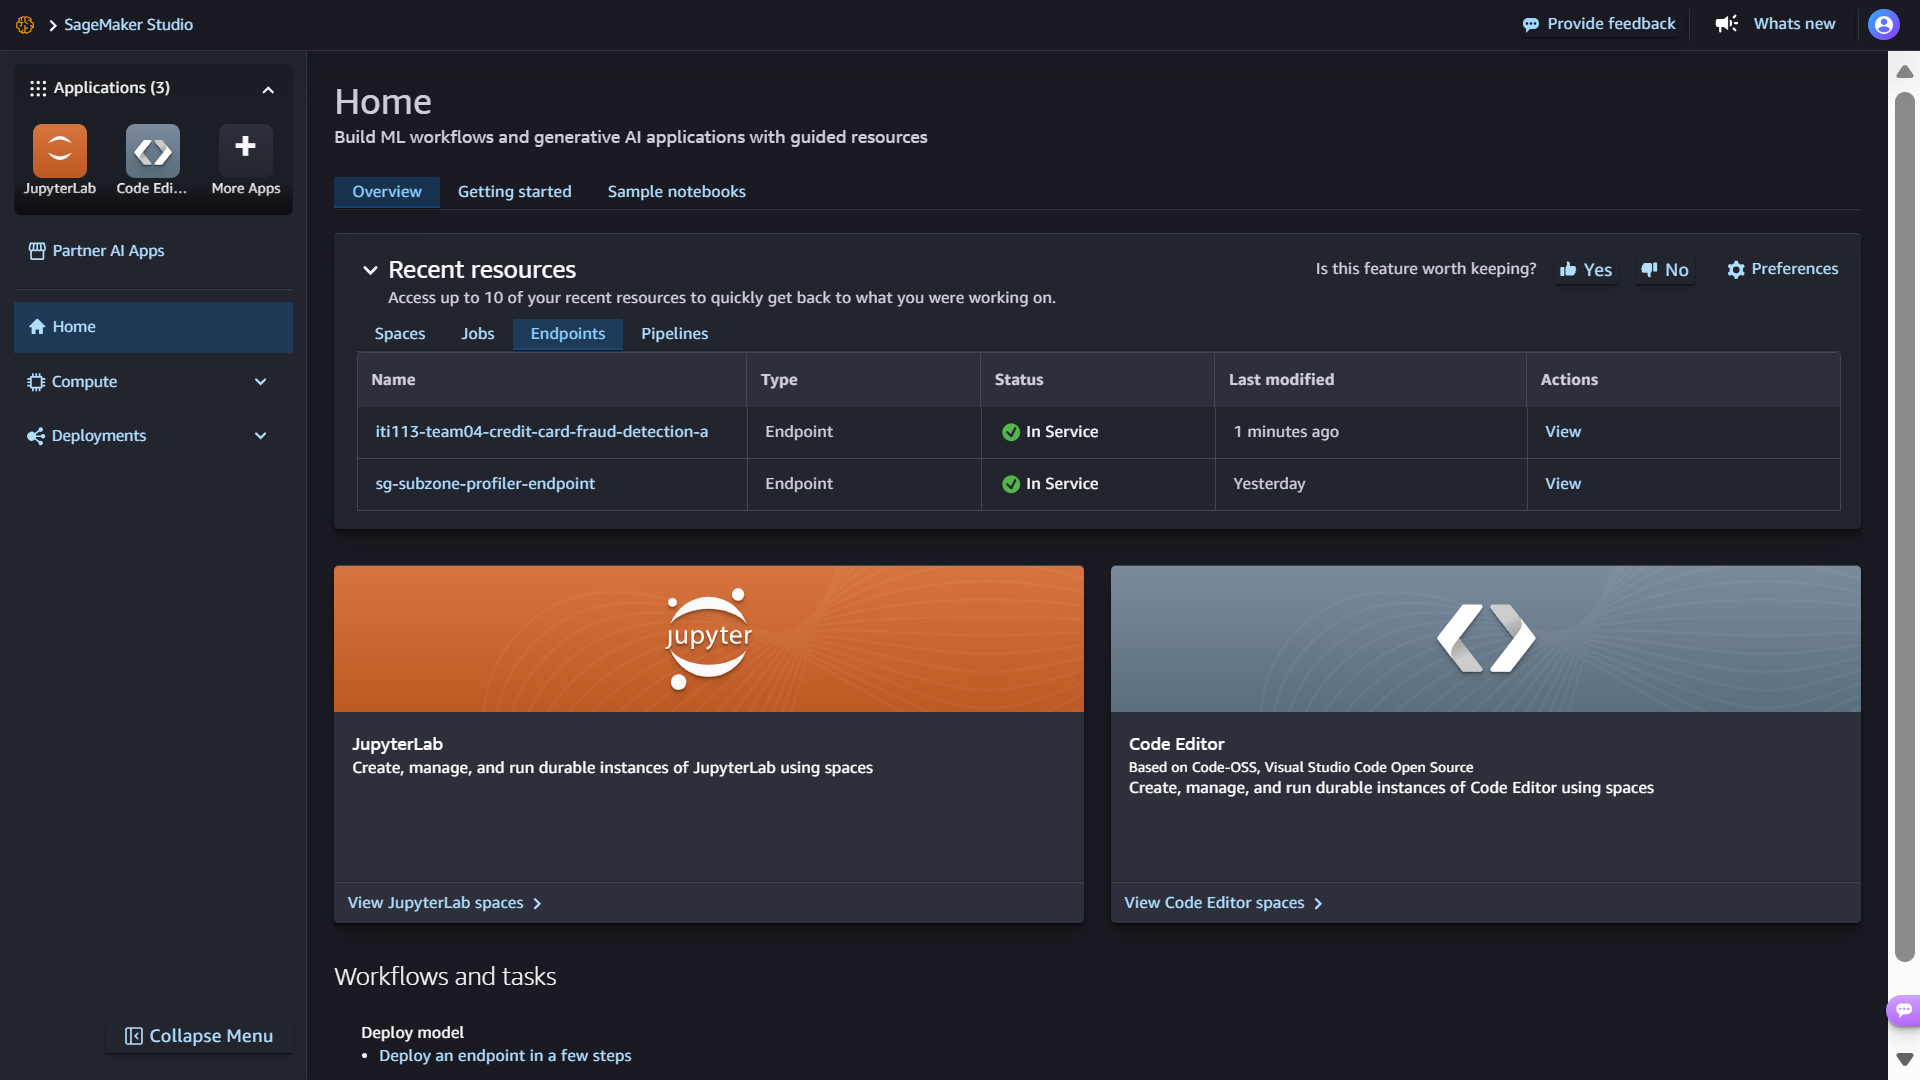
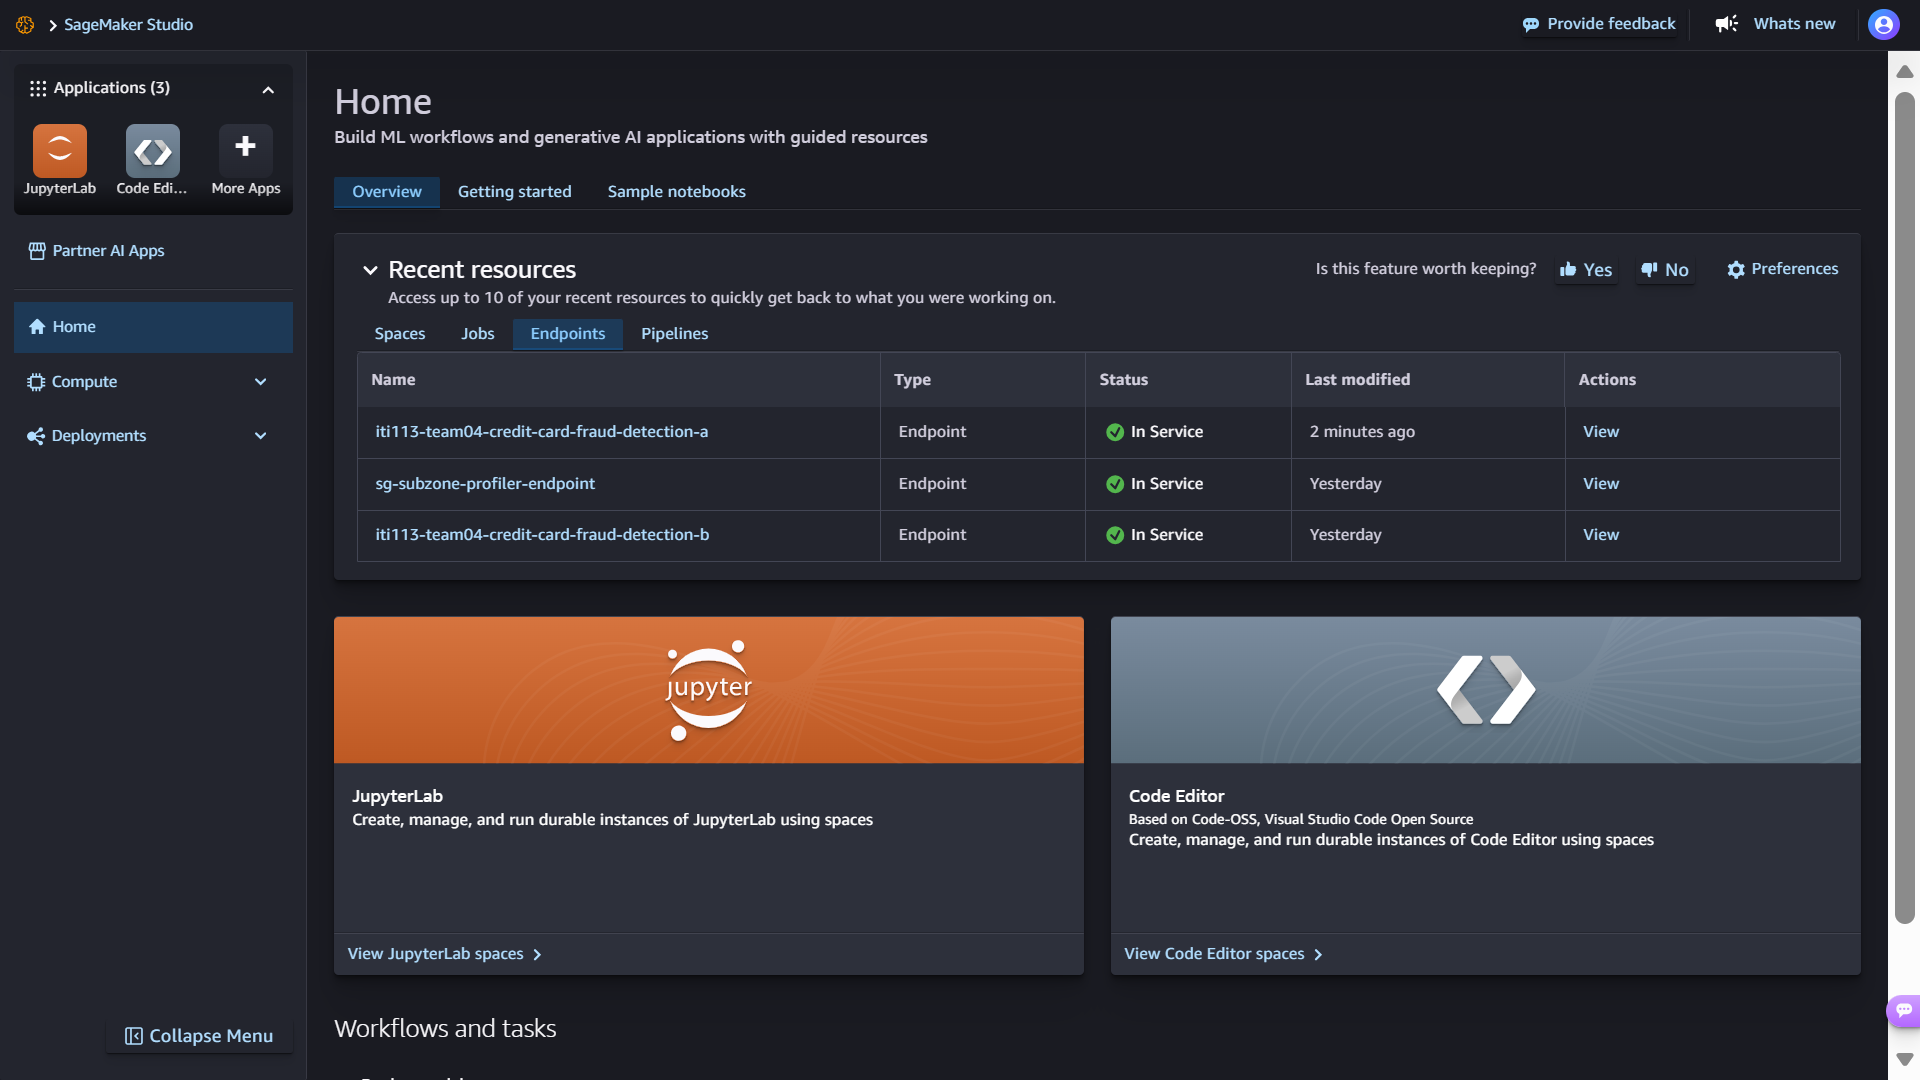

### **STEP 10: TEST THE LIVE ENDPOINT**

Starting test script...


Loaded 555719 rows from S3


Test split: 111144 rows (matches preprocess.py's held-out test set)
=== Testing Endpoint: iti113-team04-credit-card-fraud-detection-a (20 Test Cases) ===



Test Case #01 | Actual: Legitimate | Predicted: Legitimate (0.1%) | ✓ CORRECT


Test Case #02 | Actual: Legitimate | Predicted: Legitimate (0.3%) | ✓ CORRECT


...

Test Case #17 | Actual: Fraudulent | Predicted: Fraudulent (95.1%) | ✓ CORRECT


Test Case #18 | Actual: Fraudulent | Predicted: Legitimate (51.8%) | ✗ MISMATCH


Test Case #19 | Actual: Fraudulent | Predicted: Fraudulent (99.3%) | ✓ CORRECT


Test Case #20 | Actual: Fraudulent | Predicted: Fraudulent (98.3%) | ✓ CORRECT



Done.


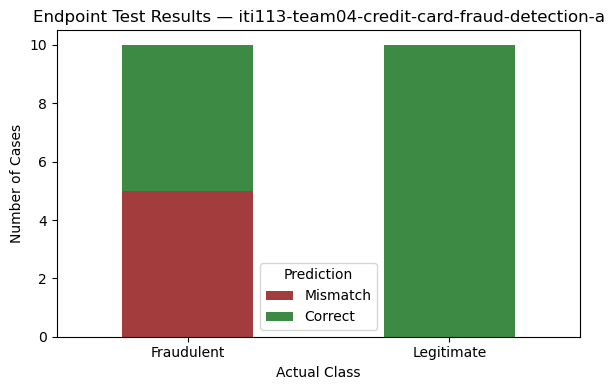


Accuracy: 15/20 (75.0%)


In [26]:
# LOAD SAMPLE FRAUD/LEGIT ROWS FROM FRAUDTEST.CSV
# TEST LIVE ENDPOINT PREDICTIONS ON 20 CASES (ACTUAL VS PREDICTED)
import json
import boto3
import pandas as pd
import matplotlib.pyplot as plt

print("Starting test script...")

from sklearn.model_selection import train_test_split

s3_path = "s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/raw/fraudTest.csv"
df = pd.read_csv(s3_path)
print(f"Loaded {len(df)} rows from S3")
X_dev, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['is_fraud'])
print(f"Test split: {len(test_df)} rows (matches preprocess.py's held-out test set)")
legit_samples = test_df[test_df['is_fraud'] == 0].sample(n=10, random_state=42)
fraud_samples = test_df[test_df['is_fraud'] == 1].sample(n=10, random_state=42)
test_samples = pd.concat([legit_samples, fraud_samples]).reset_index(drop=True)

RAW_FEATURE_COLUMNS = [
    "trans_date_trans_time", "amt", "category", "city_pop",
    "lat", "long", "merch_lat", "merch_long", "gender", "dob",
]

rt = boto3.client('sagemaker-runtime', region_name=region)
print(f"=== Testing Endpoint: {ENDPOINT_NAME} (20 Test Cases) ===\n")

results = []  # collect outcomes for the chart

for idx, row in test_samples.iterrows():
    actual_label = int(row['is_fraud'])
    actual_desc = "Fraudulent" if actual_label == 1 else "Legitimate"
    payload = row[RAW_FEATURE_COLUMNS].to_dict()
    try:
        resp = rt.invoke_endpoint(
            EndpointName=ENDPOINT_NAME,
            ContentType='application/json',
            Body=json.dumps(payload, default=str)
        )
        result = json.loads(resp['Body'].read())[0]
        pred_label = result['is_fraud_predicted']
        prob = result['fraud_probability']
        pred_desc = "Fraudulent" if int(pred_label) == 1 else "Legitimate"
        correct = (pred_desc == actual_desc)
        match_status = "✓ CORRECT" if correct else "✗ MISMATCH"
        print(f"Test Case #{idx+1:02d} | Actual: {actual_desc:<10} | Predicted: {pred_desc:<10} ({prob:.1%}) | {match_status}", flush=True)
        results.append({"actual": actual_desc, "correct": correct})
    except Exception as e:
        print(f"Test Case #{idx+1:02d} | ERROR: {type(e).__name__}: {e}", flush=True)
        results.append({"actual": actual_desc, "correct": None})  # errored, excluded from chart

print("\nDone.")

# ---- BAR CHART: correct vs mismatch, split by actual class ----
results_df = pd.DataFrame(results).dropna(subset=["correct"])
summary = results_df.groupby(["actual", "correct"]).size().unstack(fill_value=0)
summary = summary.rename(columns={True: "Correct", False: "Mismatch"})

ax = summary.plot(kind="bar", stacked=True, color={"Correct": "#3c8a44", "Mismatch": "#a33c3c"}, figsize=(6, 4))
ax.set_title(f"Endpoint Test Results — {ENDPOINT_NAME}")
ax.set_xlabel("Actual Class")
ax.set_ylabel("Number of Cases")
ax.legend(title="Prediction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("endpoint_test_results.png", dpi=150)
plt.show()

total_correct = results_df["correct"].sum()
total_tested = len(results_df)
print(f"\nAccuracy: {total_correct}/{total_tested} ({total_correct/total_tested:.1%})")

In [27]:
# INVENTORY CHECK: LIST TEAM'S ENDPOINTS AND PIPELINES BY NAME PREFIX
# MATCH TRAINING JOBS TO TEAM VIA JOB NAME PREFIX, PIPELINE EXECUTION ARN,
# OR PIPELINE HYPERPARAMETER TAGS

import boto3
import pandas as pd
from zoneinfo import ZoneInfo

sm_client = boto3.client("sagemaker")
PREFIX = "iti113-team04"
SGT = ZoneInfo("Asia/Singapore")

# 1. List Endpoints
endpoints_resp = sm_client.list_endpoints(NameContains=PREFIX, SortBy="CreationTime", SortOrder="Descending")
endpoints_data = [
    {
        "Endpoint Name": ep["EndpointName"],
        "Status": ep["EndpointStatus"],
        "Created At (SGT)": ep["CreationTime"].astimezone(SGT).strftime("%Y-%m-%d %H:%M:%S")
    }
    for ep in endpoints_resp.get("Endpoints", [])
]

# 2. List Pipelines & collect execution ARNs
pipelines_resp = sm_client.list_pipelines(PipelineNamePrefix=PREFIX, SortBy="Name", SortOrder="Descending")
pipelines_data = []
team_pipelines = []
team_exec_arns = set()

for pipe in pipelines_resp.get("PipelineSummaries", []):
    p_name = pipe["PipelineName"]
    team_pipelines.append(p_name)
    pipelines_data.append({
        "Pipeline Name": p_name,
        "Display Name": pipe.get("PipelineDisplayName", "-"),
        "Last Modified (SGT)": pipe["LastModifiedTime"].astimezone(SGT).strftime("%Y-%m-%d %H:%M:%S")
    })

    # Collect pipeline execution ARNs to match against training jobs
    try:
        execs = sm_client.list_pipeline_executions(PipelineName=p_name)
        for e in execs.get("PipelineExecutionSummaries", []):
            team_exec_arns.add(e["PipelineExecutionArn"])
    except Exception:
        pass

# 3. Identify Your Training Jobs (via tags, execution ARNs, and name prefixes)
recent_jobs = sm_client.list_training_jobs(SortBy="CreationTime", SortOrder="Descending", MaxResults=20)
my_training_jobs = []

for job in recent_jobs.get("TrainingJobSummaries", []):
    job_name = job["TrainingJobName"]
    detail = sm_client.describe_training_job(TrainingJobName=job_name)

    # Check job tags
    tags = sm_client.list_tags(ResourceArn=detail["TrainingJobArn"]).get("Tags", [])
    tag_dict = {t["Key"]: t["Value"] for t in tags}

    is_mine = False
    source = "Unknown"

    # Check 1: Job Name prefix
    if PREFIX in job_name:
        is_mine = True
        source = f"Job Name Prefix ({PREFIX})"

    # Check 2: Pipeline Execution ARN tag match
    elif "sagemaker:pipeline-execution-arn" in tag_dict:
        pipe_arn = tag_dict["sagemaker:pipeline-execution-arn"]
        if pipe_arn in team_exec_arns:
            is_mine = True
            source = f"Pipeline: {pipe_arn.split('/')[-3]}"

    # Check 3: Pipeline Hyperparameters match
    elif "sagemaker_pipeline_name" in detail.get("HyperParameters", {}):
        pipe_name = detail["HyperParameters"]["sagemaker_pipeline_name"].strip('"')
        if pipe_name in team_pipelines:
            is_mine = True
            source = f"Pipeline: {pipe_name}"

    if is_mine:
        my_training_jobs.append({
            "Training Job Name": job_name,
            "Source / Origin": source,
            "Status": job["TrainingJobStatus"],
            "Created At (SGT)": job["CreationTime"].astimezone(SGT).strftime("%Y-%m-%d %H:%M:%S")
        })

# Display Summary
print(f"=== YOUR ENDPOINTS (Prefix: '{PREFIX}') ===")
display(pd.DataFrame(endpoints_data) if endpoints_data else f"No endpoints found matching '{PREFIX}'.")

print(f"\n=== YOUR PIPELINES (Prefix: '{PREFIX}') ===")
display(pd.DataFrame(pipelines_data) if pipelines_data else f"No pipelines found matching '{PREFIX}'.")

print(f"\n=== YOUR TRAINING JOBS ===")
display(pd.DataFrame(my_training_jobs) if my_training_jobs else "No training jobs explicitly matched to your team.")

=== YOUR ENDPOINTS (Prefix: 'iti113-team04') ===


,Endpoint Name,Status,Created At (SGT)
0,iti113-team04-credit-card-fraud-detection-a,InService,2026-08-25 16:02:48



=== YOUR PIPELINES (Prefix: 'iti113-team04') ===


,Pipeline Name,Display Name,Last Modified (SGT)
0,iti113-team04-heart-disease,iti113-team04-heart-disease,2026-08-01 18:09:05
1,iti113-team04-credit-card-fraud-detection,iti113-team04-credit-card-fraud-detection,2026-08-25 15:54:41



=== YOUR TRAINING JOBS ===


,Training Job Name,Source / Origin,Status,Created At (SGT)
0,pipelines-djwiy8twj1a9-Team04-RegisterModel-n2...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-25 15:52:13
1,pipelines-djwiy8twj1a9-Team04-TrainModel-ZXYPI...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-25 15:48:02
2,pipelines-6vmxcvpdu5fs-Team04-TrainModel-1Ee7S...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-25 09:26:48
3,pipelines-wsonwktgzqj0-Team04-RegisterModel-H6...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-25 08:44:54
4,pipelines-wsonwktgzqj0-Team04-TrainModel-5QYSm...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-25 08:36:47
5,pipelines-avz60gid6oph-Team04-RegisterModel-ea...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-24 19:09:33
6,pipelines-avz60gid6oph-Team04-TrainModel-ciB71...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-24 19:01:13
7,pipelines-ijnqh01zk63y-Team04-RegisterModel-t3...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-24 16:13:29
8,pipelines-ijnqh01zk63y-Team04-TrainModel-Xg0Ht...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-24 16:10:08


### **STEP 11: PRINT NOTEBOOK 03 SUMMARY**

In [28]:
print('=' * 55)
print('NOTEBOOK 03 COMPLETE')
print('=' * 55)
print(f'Pipeline : {PIPELINE_NAME}')
print(f'MLflow   : {MLFLOW_EXPERIMENT_NAME} on SageMaker MLflow App')
print(f'MLflow App ARN : {MLFLOW_APP_ARN}')
print(f'SageMaker Registry : {MODEL_PACKAGE_GROUP}')
print(f'Endpoint : {ENDPOINT_NAME} (Serverless)')
print()

NOTEBOOK 03 COMPLETE
Pipeline : iti113-team04-credit-card-fraud-detection
MLflow   : ITI113/team04/Experiment-01 on SageMaker MLflow App
MLflow App ARN : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
SageMaker Registry : team04-credit-card-fraud-detection
Endpoint : iti113-team04-credit-card-fraud-detection-a (Serverless)



### **STEP 12: DELETE ENDPOINT WHEN NO LONGER NEEDED**

In [29]:
# To delete endpoint when no longer needed, uncomment the lines below:

# TEK | 12 AUG 2026
session = boto3.Session()
REGION = session.region_name

ENDPOINT_NAME = "iti113-team04-credit-card-fraud-detection-a"

sm_cleanup = boto3.client('sagemaker', region_name=REGION)

sm_cleanup.delete_endpoint(EndpointName=ENDPOINT_NAME)
print(f'Endpoint deleted: {ENDPOINT_NAME}')

sm_cleanup.delete_endpoint_config(EndpointConfigName=ENDPOINT_NAME)
print(f'Endpoint config deleted: {ENDPOINT_NAME}')


Endpoint deleted: iti113-team04-credit-card-fraud-detection-a
Endpoint config deleted: iti113-team04-credit-card-fraud-detection-a
